# 03 – Explainability: what drives rent?

A model that is accurate but a "black box" is hard to trust. Here we open the box of our final model (LightGBM on log(rent), trained by `src/train.py`).

1. **Feature importance** – which features does the model use most? (*global* view)
2. **SHAP values** – how much does each feature push the price up or down, for every single apartment? (*global and local* view)

In [1]:
import sys
sys.path.append("../src")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

import cleaning

# Chart style: one calm blue for data, orange only to highlight, light grey grid
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#52514e"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 130, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "axes.axisbelow": True,
    "axes.edgecolor": "#8a8983", "axes.labelcolor": GREY,
    "xtick.color": GREY, "ytick.color": GREY,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
})

In [2]:
bundle = joblib.load("../models/rent_model.joblib")
model = bundle["model"]          # TransformedTargetRegressor: log(rent) inside, euros outside
lgbm = model.regressor_          # the LightGBM model inside it (works on log(rent))
print("Test scores of this model:", bundle["metrics"])

df = cleaning.clean_data(cleaning.load_raw("../data/immo_data.csv"))
X = cleaning.prepare_features(df)
X_sample = X.sample(5_000, random_state=42)   # SHAP on 5,000 flats is plenty and fast

Test scores of this model: {'test_mae_eur': 84.5, 'test_median_abs_pct_error': 9.3, 'test_r2': 0.896}


## 1. Feature importance (LightGBM "gain")
Every time a tree splits on a feature, the prediction error gets a bit smaller. **Gain importance** adds up this improvement per feature. We show it as a share of the total.

⚠️ It tells us **how much** a feature is used, but **not in which direction** (does a lift make the flat cheaper or more expensive?). That's what SHAP is for.

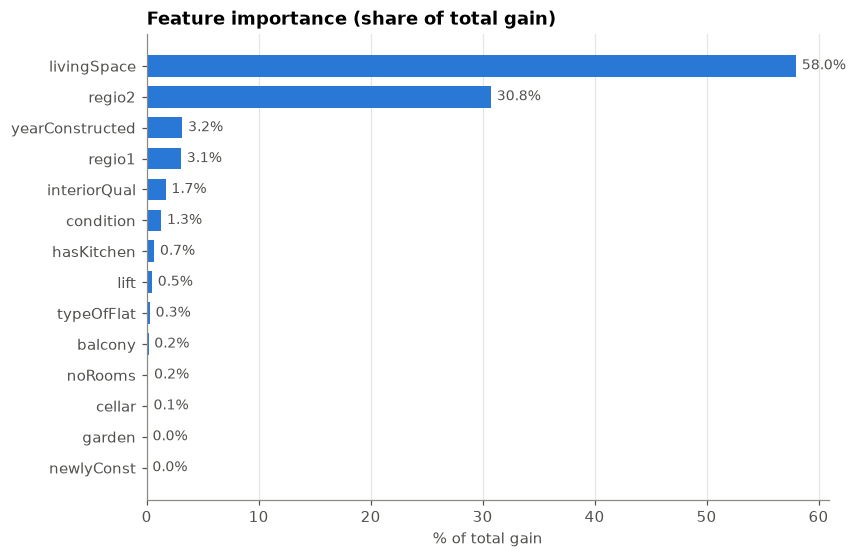

In [3]:
importance = pd.Series(lgbm.booster_.feature_importance(importance_type="gain"), index=X.columns)
importance = (importance / importance.sum() * 100).sort_values()

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(importance.index, importance.values, color=BLUE, height=0.7)
for y, value in enumerate(importance.values):
    ax.text(value + 0.5, y, f"{value:.1f}%", va="center", color=GREY, fontsize=9)
ax.set(title="Feature importance (share of total gain)", xlabel="% of total gain")
ax.grid(axis="y", visible=False)
plt.savefig("../images/feature_importance.png")
plt.show()

## 2. SHAP values
**Idea (from game theory):** the model's prediction for one flat is split fairly among its features.
Start at the **average prediction** – then every feature adds or subtracts its SHAP value – and you end at the prediction for that flat.

Our model predicts **log(rent)**, so SHAP values are on the log scale. The good news: on the log scale, *adding* means *multiplying* in euros.
**A SHAP value of +0.10 ≈ +10.5% rent, −0.10 ≈ −9.5%** (exactly: `exp(value) − 1`). Small values are roughly percentages.

In [4]:
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer(X_sample)

base_rent = np.exp(shap_values.base_values[0])
print(f"Average prediction (starting point): €{base_rent:.0f} per month")

Average prediction (starting point): €533 per month


### 2.1 Which features matter most? (mean |SHAP|)
The average size of each feature's effect, in either direction.

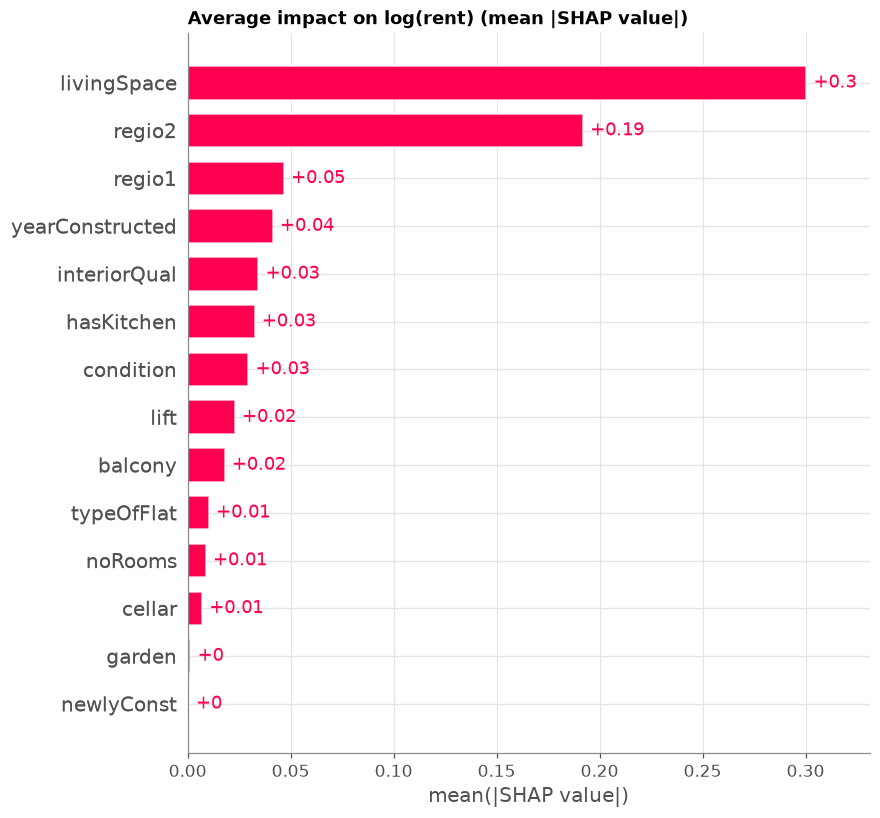

In [5]:
shap.plots.bar(shap_values, max_display=14, show=False)
plt.title("Average impact on log(rent) (mean |SHAP value|)", loc="left", fontweight="bold")
plt.savefig("../images/shap_importance.png")
plt.show()

### 2.2 Direction of the effects (beeswarm)
Each dot is one apartment. **Position**: does this feature push the rent up (right) or down (left)? **Color**: the feature's value (red = high, blue = low; grey = text categories like the city).

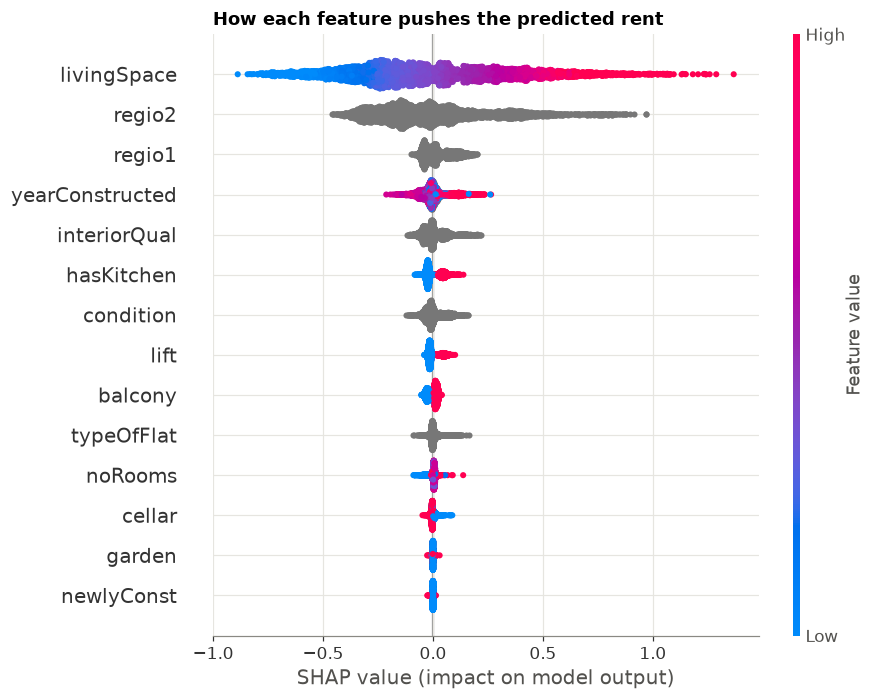

In [6]:
shap.plots.beeswarm(shap_values, max_display=14, show=False)
plt.title("How each feature pushes the predicted rent", loc="left", fontweight="bold")
plt.savefig("../images/shap_beeswarm.png")
plt.show()

### 2.3 Living space and construction year in detail

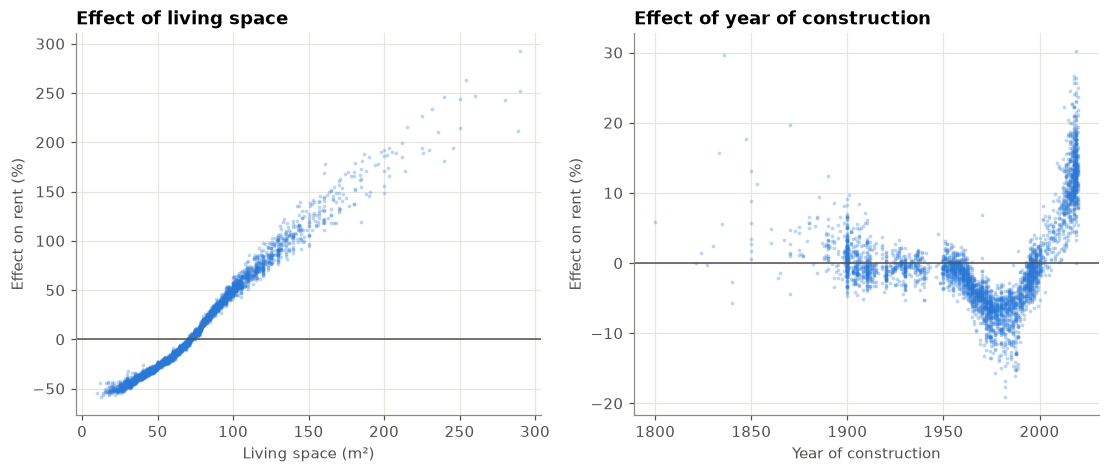

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, feature, label in [(axes[0], "livingSpace", "Living space (m²)"), (axes[1], "yearConstructed", "Year of construction")]:
    values = shap_values[:, feature]
    ax.scatter(values.data, (np.exp(values.values) - 1) * 100, s=6, alpha=0.3, color=BLUE, linewidths=0)
    ax.axhline(0, color=GREY, lw=1)
    ax.set(title=f"Effect of {label.split(' (')[0].lower()}", xlabel=label, ylabel="Effect on rent (%)")
plt.savefig("../images/shap_space_year.png")
plt.show()

### 2.4 Effect of the extras (in %)
For each yes/no feature: the average SHAP effect when the flat **has** it minus when it **doesn't**, converted to percent.

In [8]:
rows = []
for feature in cleaning.BOOLEAN_FEATURES:
    values, has_it = shap_values[:, feature].values, X_sample[feature].to_numpy() == 1
    diff = values[has_it].mean() - values[~has_it].mean()
    rows.append({"feature": feature, "share of flats with it": has_it.mean(), "effect on rent": np.exp(diff) - 1})
extras = pd.DataFrame(rows).sort_values("effect on rent", ascending=False)
extras.style.format({"share of flats with it": "{:.0%}", "effect on rent": "{:+.1%}"})

,feature,share of flats with it,effect on rent
1,hasKitchen,34%,+7.4%
2,lift,24%,+6.3%
0,balcony,62%,+3.9%
4,garden,20%,+0.1%
5,newlyConst,8%,-0.3%
3,cellar,64%,-1.4%


### 2.5 Location effect by city
Average SHAP effect of the city (`regio2`) + Bundesland (`regio1`) together, for cities with at least 30 flats in our sample.

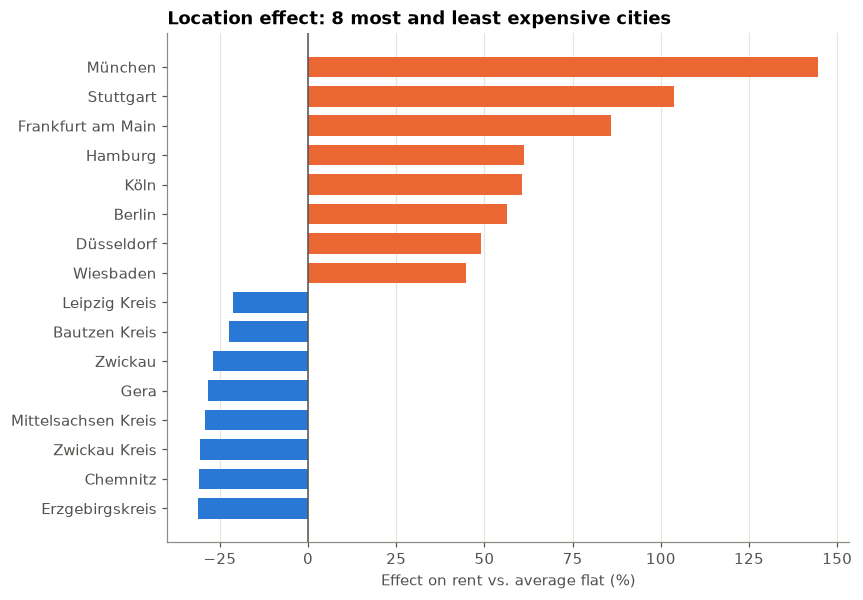

In [9]:
location = pd.DataFrame({
    "city": X_sample["regio2"].astype(str).str.replace("_", " "),
    "effect": shap_values[:, "regio2"].values + shap_values[:, "regio1"].values,
})
city_effect = location.groupby("city")["effect"].agg(["mean", "size"]).query("size >= 30")["mean"]
city_effect = (np.exp(city_effect) - 1) * 100
top_bottom = pd.concat([city_effect.nsmallest(8), city_effect.nlargest(8).iloc[::-1]]).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_bottom.index, top_bottom.values, color=[ORANGE if v > 0 else BLUE for v in top_bottom.values], height=0.7)
ax.axvline(0, color=GREY, lw=1)
ax.set(title="Location effect: 8 most and least expensive cities", xlabel="Effect on rent vs. average flat (%)")
ax.grid(axis="y", visible=False)
plt.savefig("../images/shap_city_effect.png")
plt.show()

### 2.6 One apartment explained (waterfall)
SHAP can also explain a **single** prediction – useful to show a user *why* the app gives a certain estimate.

livingSpace                66.34
noRooms                      2.0
yearConstructed              NaN
balcony                        1
hasKitchen                     1
lift                           0
cellar                         1
garden                         1
newlyConst                     0
regio1                    Berlin
regio2                    Berlin
condition              well_kept
typeOfFlat             apartment
interiorQual       sophisticated

Actual rent: €637 | Predicted: €800


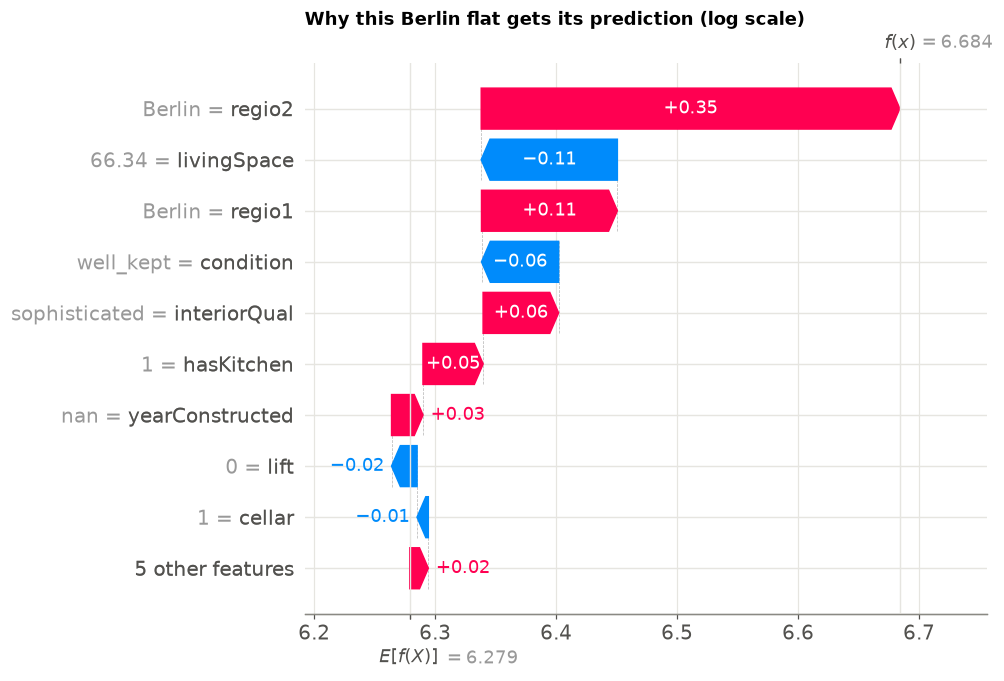

In [10]:
example_idx = X_sample.index.get_loc(X_sample.query("regio2 == 'Berlin' and 65 <= livingSpace <= 75").index[0])
example = X_sample.iloc[example_idx]
print(example.to_string())
print(f"\nActual rent: €{df.loc[X_sample.index[example_idx], 'baseRent']:.0f} | "
      f"Predicted: €{model.predict(X_sample.iloc[[example_idx]])[0]:.0f}")

shap.plots.waterfall(shap_values[example_idx], max_display=10, show=False)
plt.title("Why this Berlin flat gets its prediction (log scale)", loc="left", fontweight="bold")
plt.savefig("../images/shap_waterfall_example.png")
plt.show()

In [11]:
# The same in percent: how much each feature changes this flat's rent vs. the average flat
effects = pd.Series(shap_values[example_idx].values, index=X.columns)
(np.exp(effects.sort_values(key=abs, ascending=False)) - 1).map("{:+.1%}".format).to_frame("effect on rent")

,effect on rent
regio2,+41.3%
livingSpace,-10.6%
regio1,+11.9%
condition,-6.2%
interiorQual,+6.4%
hasKitchen,+5.1%
yearConstructed,+2.6%
lift,-2.1%
cellar,-0.9%
balcony,+0.9%


## 3. What we learned (Phase 5)

**1. Size and location are almost everything.** Living space (58% of the gain) and the city (31%) dominate; SHAP agrees (mean |SHAP| 0.30 and 0.19, everything else ≤ 0.05). The Bundesland adds a little on top of the city.

**2. Living space:** the effect grows steadily – a 30 m² flat is about **−48%** vs. the average flat, 100–150 m² about **+77%**. The curve flattens slightly for very large flats: each extra m² adds a bit less.

**3. Location:** with everything else equal, a flat in **München costs ~2.5× the average (+145%)**, Stuttgart +104%, Frankfurt +86%, Hamburg/Köln +61%, Berlin +56%. The cheapest regions are all in **Saxony and Thuringia** (Chemnitz, Erzgebirgskreis, Zwickau, Gera: about −30%).

**4. Construction year:** a **U-shape**. Old buildings (pre-1950, *Altbau*) are about average, buildings from **1970–1990 are the cheapest (≈ −7%, down to −15%)**, and new buildings after 2010 are **+12%** (up to +25% for the newest).

**5. Quality matters, but less than you might think:**
- `interiorQual`: luxury **+15%**, sophisticated +5%, normal −5%, simple −8%
- `condition`: first time use **+8%**, mint condition +4%, need of renovation **−9%**
- `typeOfFlat`: penthouse **+8%**, half basement −4%

**6. Extras:** fitted kitchen **+7%**, lift **+6%**, balcony **+4%**. Garden and "newly constructed" add ~0% – the model already gets this information from the construction year and other features.

**⚠️ Correlation, not cause:** SHAP explains *what the model learned*, not what *causes* higher rents. Example: a cellar shows −1.4% – a cellar does not make a flat cheaper, but flats with a cellar are more often in older, cheaper buildings.

**Local explanation:** for the example Berlin flat (66 m², predicted €800, actual €637) the city pushes the price up by +41%, the slightly-below-average size pulls it down by −11%. This kind of breakdown can be shown in the app next to each prediction.
